# Basin Delineation - Loop (SLS modified)

## 1) Importing Packages

In [1]:
# !pip install pysheds netCDF4 fiona geopandas xarray pyshp

In [2]:
# IMPORT PACKAGES
import pysheds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import fiona
import xarray as xr
import shapefile
import math
from scipy import stats
import os
from numpy import random
import netCDF4 as nc
from netCDF4 import Dataset
from shapely.geometry import Point, shape, box, mapping, Polygon, MultiPolygon
from shapely.vectorized import contains
from shapely.strtree import STRtree
import matplotlib.path as mpath

from rasterio.transform import rowcol
from rasterio.coords import BoundingBox
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.features import shapes
print('packages have been imported!')

packages have been imported!


## 2) Define Filepaths and Open Station Masterfile


In [3]:
# Load the master list
masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_AllMonthly.csv'
stations_df = pd.read_csv(masterlist)
station_num = stations_df['grdc_no']

# Load the Stations
monthly_path = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/STATIONS/'
station_files = [os.path.join(monthly_path, f"{station_no}_Q_Month.txt") for station_no in station_num]
shp_log = np.zeros(len(station_files))
print(f"Loaded {len(station_files)} stations.")
stations_df.head()

Loaded 575 stations.


,grdc_no,wmo_reg,sub_reg,river,station,country,lat,long,area,altitude,...,m_start,m_end,m_yrs,m_miss,t_start,t_end,t_yrs,lta_discharge,r_volume_yr,r_height_yr
0,1159100,1,1591,ORANGE RIVER,VIOOLSDRIF (27811003),ZA,-28.757990,17.721591,866486.0,152.0,...,1935.0,2022.0,88.0,5.379443,1935,2024,90,251.426,7.928970336,9.150719499218683
1,1159103,1,1591,ORANGE RIVER,PELLA MISSION,ZA,-28.963403,19.151922,859920.0,-999.0,...,1979.0,2022.0,44.0,8.789062,1979,2024,46,132.007,4.162972752,4.841116327100195
2,1159105,1,1591,ORANGE RIVER,SENDELINGSDRIF,ZA,-28.075833,16.898333,985370.0,-999.0,...,2014.0,2020.0,7.0,0.000000,2014,2024,11,30.913,0.9748723680000001,0.9893465074033104
3,1159125,1,1591,RENOSTERRIVIER,LEEUWENKUIL,ZA,-31.437160,20.474169,8938.0,-999.0,...,1987.0,2022.0,36.0,17.619048,1987,2023,37,0.487,0.015358032,1.718285074960841
4,1159130,1,1591,SAK,HOL PADS LEEGTE (27814016),ZA,-30.474712,20.519176,40073.0,919.0,...,1973.0,2022.0,50.0,3.891709,1973,2024,52,2.358,0.074361888,1.855660619369651


### > Create a random subset

In [64]:
# Create a Subset...
random_subset = stations_df.sample(n=10, random_state=41)
print('Created a random subset')
random_subset.head()

Created a random subset


,grdc_no,wmo_reg,sub_reg,river,station,country,lat,long,area,altitude,...,m_start,m_end,m_yrs,m_miss,t_start,t_end,t_yrs,lta_discharge,r_volume_yr,r_height_yr
422,4149413,4,4491,TOMBIGBEE RIVER,"COFFEEVILLE L+D NEAR COFFEEVILLE, AL",US,31.7585,-88.1292,47700.0,-999.00,...,NaN,NaN,NaN,NaN,1960,2021,62,841.031,26.522753616,556.0325705660376
307,3650415,3,3508,RIO DAS BALSAS,BALSAS,BR,-7.5344,-46.0358,8800.0,235.00,...,1965.0,1993.0,29.0,0.593472,1965,2020,56,100.853,3.180500208,361.4204781818182
352,4118320,4,4180,AMARGOSA RIVER,"TECOPA, CA",US,35.8486,-116.2300,8003.1,399.29,...,1961.0,2000.0,40.0,39.743590,1961,2023,63,0.077,0.002428272,0.3034164261348727
194,3621400,3,3211,RIO CAQUETA,VILA BITTENCOURT,BR,-1.3947,-69.4283,197136.0,-999.00,...,1980.0,1993.0,14.0,1.273885,1980,2020,41,13931.837,439.354411632,2228.686853907962
133,2856500,2,2561,GODAVARI RIVER,MANCHERIAL,IN,18.8300,79.4500,102900.0,124.00,...,1968.0,2024.0,57.0,9.037037,1968,2024,57,299.712,9.451717632,91.8534269387755


In [4]:
random_subset = stations_df.iloc[228:]
(random_subset)

,grdc_no,wmo_reg,sub_reg,river,station,country,lat,long,area,altitude,...,m_start,m_end,m_yrs,m_miss,t_start,t_end,t_yrs,lta_discharge,r_volume_yr,r_height_yr
228,3634400,3,3341,RIO YACO,SERINGAL SAO JOSE,BR,-9.3744,-68.7239,10471.0,-999.000,...,NaN,NaN,NaN,NaN,1981,2020,40,230.548,7.270561728000001,694.3521848916054
229,3634450,3,3341,RIO CAETE,SERINGAL GUARANY,BR,-9.1103,-68.9933,6025.0,-999.000,...,NaN,NaN,NaN,NaN,1983,2020,38,134.095,4.22881992,701.8788248962655
230,3634500,3,3341,RIO MUCUIM,CRISTO,BR,-7.4647,-64.2433,6482.0,-999.000,...,1975.0,1989.0,15.0,4.761905,1975,2019,45,257.262,8.113014432,1251.622096883678
231,3635030,3,3351,RIO MADERA,MANICORE,BR,-5.8167,-61.3019,1150000.0,-999.000,...,1967.0,1993.0,27.0,11.875000,1967,2020,54,23840.189,751.824200304,653.7601741773913
232,3635035,3,3351,RIO MADERA,HUMAITA,BR,-7.5028,-63.0183,1090000.0,-999.000,...,NaN,NaN,NaN,NaN,1967,2020,54,22057.054,695.5912549440001,638.1571146275229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,5709100,5,5096,ROPER RIVER,RED ROCK,AU,-14.6968,134.4220,47400.0,31.270,...,1966.0,2001.0,36.0,8.095238,1966,2023,58,94.717,2.986995312,63.01677873417722
571,5709105,5,5096,ELSEY CREEK,HRS WARLOCH PONDS,AU,-15.0854,133.1229,6784.0,27.690,...,NaN,NaN,NaN,NaN,1969,2022,54,4.377,0.138033072,20.34685613207547
572,5709110,5,5094,MCARTHUR RIVER,M.I.M. PUMP,AU,-16.4519,136.0850,10400.0,37.000,...,1969.0,2001.0,33.0,12.598425,1969,2024,56,19.042,0.6005085120000001,57.74120307692309
573,5709112,5,5094,MCARTHUR RIVER,BORROLOOLA CROSSING,AU,-16.0818,136.3170,15700.0,31.435,...,NaN,NaN,NaN,NaN,1975,2024,50,52.89,1.66793904,106.2381554140127


## 3) Define Methods

In [4]:
def crop_dem(input_tif, output_tif, center_lon, center_lat,area, plot_scene = True):
    """
    Crop a GeoTIFF file around a specified coordinate (center_lon, center_lat), save the cropped image,
    display the cropped area, and plot a scatter point at the center coordinates.
    """

    # # Define the path to the input and output TIFF files
    # input_tiff = "path/to/your/input.tif"
    # output_tif = "path/to/your/output_cropped.tif"
    """
    if area < 10000:
      width = np.sqrt(area)*4 # width extending from center point to each edge of square
    else:
      width = np.sqrt(area)*2
    """

    if area < 10000:
      width = np.sqrt(area)*6 # width extending from center point to each edge of square
    elif 10000< area < 50000:
      width = np.sqrt(area)*5
    elif 50000< area < 200000:
      width = np.sqrt(area)*4
    else:
      width = np.sqrt(area)*3

    width = int(width)
    degrees = np.round(width/111.32,2)

    xmin = center_lon - degrees
    xmax = center_lon + degrees
    ymin = center_lat - degrees
    ymax = center_lat + degrees

    # Define the bounding box coordinates (left, bottom, right, top)
    bbox = (xmin, ymin, xmax, ymax)  # Replace with actual coordinates

    # Open the source TIFF file
    with rasterio.open(input_tif) as src:
        # Convert the bounding box to a GeoJSON-style geometry for rasterio.mask.mask
        bbox_geom = {
            "type": "Polygon",
            "coordinates": [[
                [bbox[0], bbox[1]],
                [bbox[0], bbox[3]],
                [bbox[2], bbox[3]],
                [bbox[2], bbox[1]],
                [bbox[0], bbox[1]]
            ]]
        }

        # Crop the image using the bounding box geometry
        out_image, out_transform = mask(src, [bbox_geom], crop=True)
        out_meta = src.meta.copy()

        # Update metadata to reflect the new cropped area
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            'crs': src.crs  # Ensure the CRS remains the same
        })

        # # Save the cropped data to a new GeoTIFF file with updated profile
        # profile = src.profile
        # profile.update({
        #     'height': height,
        #     'width': width,
        #     'transform': transform,
        #     'crs': src.crs  # Ensure CRS is preserved
        # })

        with rasterio.open(output_tif, 'w', **out_meta) as dst:
            dst.write(out_image)


    # Plot the image using rasterio's show function
    if plot_scene == True:
        fig, ax = plt.subplots(figsize=(10, 10))

        # Calculate the extent of the image in geographic coordinates
        left = out_transform.c  # xmin
        right = out_transform.c + out_transform.a * out_image.shape[2]  # xmax
        top = out_transform.f  # ymax
        bottom = out_transform.f + out_transform.e * out_image.shape[1]  # ymin
    
        extent = (left, right, bottom, top)
        show(out_image, transform=out_transform, extent=extent, ax=ax, cmap='gray')
        # Set axis labels
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        # Add a scatter point at the center coordinate
        plt.scatter(center_lon, center_lat, color='red', marker='o', s=100, label="Center Point")
        plt.title("Cropped GeoTIFF Area with Center Point")
        plt.title("Cropped Image")
        plt.show()
    return(out_image,bbox)

In [5]:
def open_and_crop_basin(index, plot_scene = True):
    print('\n1: Running crop method...')
    # 1) Load the station
    data = stations_df.iloc[index]

    # Assign vars
    number = data['grdc_no']
    region = data['wmo_reg']
    river = data['river']
    name = data['station']
    lat = data['lat']
    lon = data['long']
    area = data['area']
    altitude = data['altitude']
    print(f'  Station {number}\n   name: {name}\n   region: {region}\n   lon,lat: {lon},{lat}')

    # 2) Assign region
    SCRATCH_DIR = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM'
    if region == 1:
      dem = f'{SCRATCH_DIR}/hyd_af_dem_30s.tif'
    elif region == 2:
      dem = f'{SCRATCH_DIR}/hyd_as_dem_30s.tif'
    elif region == 3:
      dem = f'{SCRATCH_DIR}/hyd_sa_dem_30s.tif'
    elif region == 4:
      dem = f'{SCRATCH_DIR}/hyd_na_dem_30s.tif'
    elif region == 5:
      dem = f'{SCRATCH_DIR}/hyd_au_dem_30s.tif'
    elif region == 6:
      dem = f'{SCRATCH_DIR}/hyd_eu_dem_30s.tif'
    print(f'   DEM: {dem}')
    output_tif = f'/global/scratch/users/slsmit34/299/STATIONS/{number}_dem.tif' #Set to my dir because I do not have permissions to create in Cynthia's

    # 3) crop the region
    output_dem, bbox = crop_dem(dem, output_tif, lon, lat,area, plot_scene)

    return(bbox, lat,lon,area,number,output_tif, dem)

In [6]:
def delineate_basin_1(output_tif, lon, lat, dem, number, plot_scene = True):
    print('\n2a: Running delineation part 1...')
    # GET THE FLOW MAP!
    # Load the .tif file for the DEM
    tif_input = output_tif
    pour_point = [lon,lat]
    print(f'   Target lon/lat:{pour_point}')
    
    # Make dir for output tif...
    new_folder_path = f'/global/scratch/users/slsmit34/299/STATIONS/{number}/'
    os.makedirs(new_folder_path, exist_ok=True)
    shp_name = new_folder_path + f'{number}.shp'

    # Initialize a grid from the raster
    grid = Grid.from_raster(tif_input, data_name='dem')
    dem = grid.read_raster(tif_input)

    # Condition dem
    pit_filled_dem = grid.fill_pits(dem)
    flooded_dem = grid.fill_depressions(pit_filled_dem)
    inflated_dem = grid.resolve_flats(flooded_dem)

    # Define the flow direction map (Dirmap)
    dir_map = (64, 128, 1, 2, 4, 8, 16, 32)
    f_dir = grid.flowdir(inflated_dem, dirmap=dir_map)  # returns a Raster object
    print(np.nanmin(f_dir))
    
    # Plot the flow direction map
    if plot_scene == True:
        fig = plt.figure(figsize=(8,6))
        fig.patch.set_alpha(0)
        
        plt.imshow(f_dir, extent=grid.extent, cmap='viridis', zorder=2)
        plt.scatter(lon, lat, color='red', marker='o', s=100, label="Center Point")
        boundaries = ([0] + sorted(list(dir_map)))
        plt.colorbar(boundaries= boundaries,
                     values=sorted(dir_map))
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('Flow direction grid', size=14)
        plt.grid(zorder=-1)
        plt.tight_layout()
    return(grid, dem, f_dir, dir_map, shp_name) 

In [7]:
def delineate_basin_2(grid, dem, f_dir, dir_map, lon, lat, plot_scene = True):
    print('\n2b: Running delineation part 2...')
    # Get Accumulation
    acc = grid.accumulation(f_dir, dirmap=dir_map)
    acc[dem==0] = 0

    # Delin basin
    row, col = rowcol(acc.affine, lon, lat)
    # Access the accumulation value
    acc_atpt = acc.view()[row, col]
    acc_max = int(acc.max())
    arr = acc.view()
    
    # Define half-window size (9x9 = 4 px in each direction)
    half_size = 4
    
    # Create a window around the pour-point to snap to
    row_start = max(0, row - half_size)
    row_end   = min(arr.shape[0], row + half_size + 1)
    col_start = max(0, col - half_size)
    col_end   = min(arr.shape[1], col + half_size + 1)
    
    # Extract the window
    window = arr[row_start:row_end, col_start:col_end]

    # Exported metrics
    print('\n  STATS-----')
    print("   Flow accumulation at point: ", acc_atpt)
    print("   Max accumulation: ", acc_max)
    avg_full_area = (acc_max+acc_atpt)/2
    print("   Average of full area: ", avg_full_area) # ((acc_max+acc_atpt)/2))
    window_shape = window.shape
    print("   Window shape:", window_shape) # window.shape)
    max_acc_window = np.max(window)
    print("   Max accumulation in 9x9: ", max_acc_window)# np.max(window)) 
    mean_acc_window = np.mean(window)
    print("   Avg accumulation in 9x9: ", mean_acc_window)#np.mean(window)) 
    
    # Define the accumulation of the snapped point
    snap_pt = np.max(window)
    x_snap, y_snap = grid.snap_to_mask(acc > snap_pt, (lon, lat))
    catch = grid.catchment(x=x_snap, y=y_snap, fdir=f_dir, dirmap=dir_map,
                              xytype='coordinate')
    
    # Convert lon/lat to raster indices
    row_snap, col_snap = rowcol(acc.affine, x_snap, y_snap)
    # Access the accumulation value
    acc_snapped = acc.view()[row_snap, col_snap]
    acc_area = np.size(acc)
    print(acc_area)#np.size(acc))
    print(lon,lat)
    print(x_snap, y_snap)
    print("   Accumulation at snapped point: ", acc_snapped)

    # # Clip the bounding box to the catchment
    # grid.clip_to(catch)
    catch_view = grid.view(catch, dtype=np.uint8)

    if plot_scene == True:
        fig, ax = plt.subplots(figsize=(8,6))
        fig.patch.set_alpha(0)
        plt.grid('on', zorder=0)
        im = ax.imshow(acc, extent=catch.extent, zorder=1,
                        cmap='ocean',
                        norm=colors.LogNorm(1, acc.max()),
                        interpolation='bilinear')
        plt.colorbar(im, ax=ax, label='Upstream Cells')
        plt.imshow(np.where(catch_view,catch_view, np.nan), extent=grid.extent,zorder=2, cmap='Greys',alpha=0.3)
        plt.scatter(lon,lat, color='yellow', s=10, marker='o', zorder=3)
        plt.scatter(x_snap,y_snap, color='red', s=10, marker='o', zorder=3)
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.tight_layout()
        plt.show()
    return(catch_view, catch, acc, x_snap, y_snap, acc_atpt, acc_max, avg_full_area, window_shape, max_acc_window, mean_acc_window, acc_area, acc_snapped)

def extract_holes(geom):
    """Return holes (interior rings) as polygons."""
    holes = []
    if geom.geom_type == "Polygon":
        for interior in geom.interiors:
            holes.append(Polygon(interior))
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            for interior in poly.interiors:
                holes.append(Polygon(interior))
    return holes


In [8]:
def get_utm_epsg(gdf): #need input grdc_shp

    # check lat/lon
    gdf_latlon = gdf.to_crs(4326)
    centroid = gdf_latlon.geometry.centroid
    lon = centroid.x.mean()
    lat = centroid.y.mean()
    print(f'calculated lat/lon, get_utm_espg fxn: {lon}, {lat}')
    
    # get utm zone, calc espg
    utm_zone = int((lon + 180) / 6) + 1
    epsg_code = 32600 + utm_zone if lat >= 0 else 32700 + utm_zone
    return epsg_code


In [9]:
def compare_catchments(grid, catch_view, acc, catch, x_snap, y_snap, lon, lat, number, shp_name, area_GRDC):
    print('\n3: Running comparison...')
    shapes = grid.polygonize(catch_view)

    # Specify schema
    schema = {
            'geometry': 'Polygon',
            'properties': {'LABEL': 'float:16'}
    }

    # Write shapefile of the delineated catchment
    shp_output = shp_name
    with fiona.open(
        shp_output,
        'w',
        driver='ESRI Shapefile',
        crs=grid.crs.srs,
        schema=schema
    ) as c:
        i = 0
        for geom, value in shapes:
            g = shape(geom)
    
            # Extract interior rings (the regions you actually want)
            holes = extract_holes(g)
    
            # If no holes, just write the geometry itself
            if not holes:
                rec = {
                    "geometry": g.__geo_interface__,
                    "properties": {"LABEL": str(value)},
                    "id": str(i),
                }
                c.write(rec)
                i += 1
            else:
                # Write each hole as its own polygon feature
                for h in holes:
                    rec = {
                        "geometry": h.__geo_interface__,
                        "properties": {"LABEL": str(value)},
                        "id": str(i),
                    }
                    c.write(rec)
                    i += 1
                    
    # Read the shapefiles
    delin_shp = gpd.read_file(shp_output) # delineated shapefile
    # shapefile1 = catch_view
    grdc_shp = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp') # GRDC shapefile
    
    # Step 3: Reproject to a projected CRS (e.g., UTM Zone 33N, replace EPSG:32633 as appropriate)
    espg_code = get_utm_epsg(grdc_shp)
    print(f' CALCED ESPG: {espg_code}')
    projected_crs = grdc_shp.to_crs(epsg=espg_code)#32633)  # Use an appropriate EPSG for your region
    delin_shp = delin_shp.to_crs(projected_crs.crs)
    grdc_shp = grdc_shp.to_crs(projected_crs.crs)
    
    # Calculate the intersection
    intersection = gpd.overlay(delin_shp, grdc_shp, how='intersection')
    #print(intersection)
    
    # Calculate the area of the intersection (in m2)
    intersection_area = intersection.dissolve().geometry.area
    delin_area = delin_shp.dissolve().geometry.area
    grdc_area = grdc_shp.dissolve().geometry.area
    print('established area')
    print(f'intersection area: {intersection_area.to_list()}')
    print(f'delin area: {delin_area.to_list()}')
    print(f'calculated grdc area: {grdc_area.to_list()}')
    print(f'csv reported grdc area: {area_GRDC}')
    inter_pcnt = ((intersection_area[0])/grdc_area[0])*100
    print(inter_pcnt)
    print(grdc_shp.crs)
    print(delin_shp.crs)

    # save plot
    gdf_delin = gpd.read_file(shp_output)
    gdf_grdc = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp')
    
    fig, ax = plt.subplots(figsize=(8,6))
    fig.patch.set_alpha(0)
    
    # Flow accumulation background
    im = ax.imshow(
        acc,
        extent=catch.extent,
        zorder=1,
        cmap="ocean",
        norm=colors.LogNorm(1, acc.max()),
        interpolation="bilinear"
    )
    
    # Colorbar
    plt.colorbar(im, ax=ax, label="Upstream Cells")
    
    # Overlay shapefiles instead of NaN mask
    gdf_delin.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=2)
    gdf_delin.plot(ax=ax, facecolor="red", edgecolor="red", alpha=0.5, zorder=2)
    
    gdf_grdc.boundary.plot(ax=ax, edgecolor="black", linewidth=.6, zorder=2)
    gdf_grdc.plot(ax=ax, facecolor="yellow", edgecolor="yellow", alpha=0.5, zorder=2)
    
    # Snap point
    ax.scatter(x_snap, y_snap, facecolor="red", edgecolor = 'black', s=90, linewidth = 2, marker="s", zorder=4, label = 'snapped')
    ax.scatter(lon, lat, facecolor="yellow",edgecolor = 'black', linewidth = 2, s=50, marker="o", zorder=4, label = 'GRDC original')
    
    # Labels, formatting
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha = 0.5, zorder=0)

    # Set limits
    grdc_bounds = gdf_grdc.geometry.bounds
    delin_bounds = gdf_delin.geometry.bounds

    minx = min(grdc_bounds['minx'].min(), delin_bounds['minx'].min())
    miny = min(grdc_bounds['miny'].min(), delin_bounds['miny'].min())
    maxx = max(grdc_bounds['maxx'].max(), delin_bounds['maxx'].max())
    maxy = max(grdc_bounds['maxy'].max(), delin_bounds['maxy'].max())
    print(minx, maxx, miny, maxy)
    # HATCHING OF INTERSECTION
    intersection_crs_adjust = intersection.to_crs(gdf_grdc.crs)
    
    if not intersection.empty:
        intersection_crs_adjust.plot(
            ax=ax,
            facecolor="none",
            edgecolor="black",
            hatch="....",   
            linewidth=0.0,
            zorder=3
            #label="Overlap Area"
        )
        intersection_crs_adjust.boundary.plot(ax=ax, color="black", linewidth=1, linestyle="--", zorder=3, label = 'Overlap')
    
    #---
    # ADD A LEGEND
    plt.legend()
    plt.tight_layout()
    plt.title(f'Station ID {number}\nGRDC Index {n}')
    plt.xlim(int(minx-1), int(maxx+1))
    plt.ylim(int(miny-1), int(maxy+1))
    #output_fn = f'/global/scratch/users/slsmit34/299/intersection_delin_plots/{number}_{n}.png'
    output_fn = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/intersection_delin_plots/{number}_{n}_UPDATEDEM.png'
    plt.savefig(output_fn,dpi=300, bbox_inches='tight')
    plt.show()
    return(gdf_grdc, grdc_area, intersection_area, inter_pcnt, output_fn, delin_area, delin_shp,grdc_shp)

## 4) Create Empty DF

In [10]:
# Create the df
import pandas as pd
cols = [
    "Country","Station", "Index", "lat", "lon",
    "lat_snap_y", "lon_snap_x",
    "area_grdc_km2", "area_delineated_km2", "area_intersect_km2", "pct_intersect", "avg_acc_of_full_area",
    "img_path",
    "flow_accum_at_pour_pt", "snapped_accum", "max_accum", "avg_accum", 
    "win_shape", "max_accum_9x9", "avg_accum_9x9", "estimated_distance_km",
    "FLAG_small_areaDelin<1000", "FLAG_small_snapAcc<100", "FLAG_small_Intersec<90", "FLAG_cropping_GRDC>cropDEM"
]

# Initialize empty dataframe
df = pd.DataFrame(columns=cols)
print('Empty df for the loop:')
df.head()

Empty df for the loop:


,Country,Station,Index,lat,lon,lat_snap_y,lon_snap_x,area_grdc_km2,area_delineated_km2,area_intersect_km2,...,max_accum,avg_accum,win_shape,max_accum_9x9,avg_accum_9x9,estimated_distance_km,FLAG_small_areaDelin<1000,FLAG_small_snapAcc<100,FLAG_small_Intersec<90,FLAG_cropping_GRDC>cropDEM


## 5) Run the Loop

[1]/[1]~~ RUNNING RANDOM SUBSET, NUMBER 200 ~~

1: Running crop method...
  Station 3626000
   name: MANACAPURU
   region: 3
   lon,lat: -60.6094,-3.3106
   DEM: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_sa_dem_30s.tif


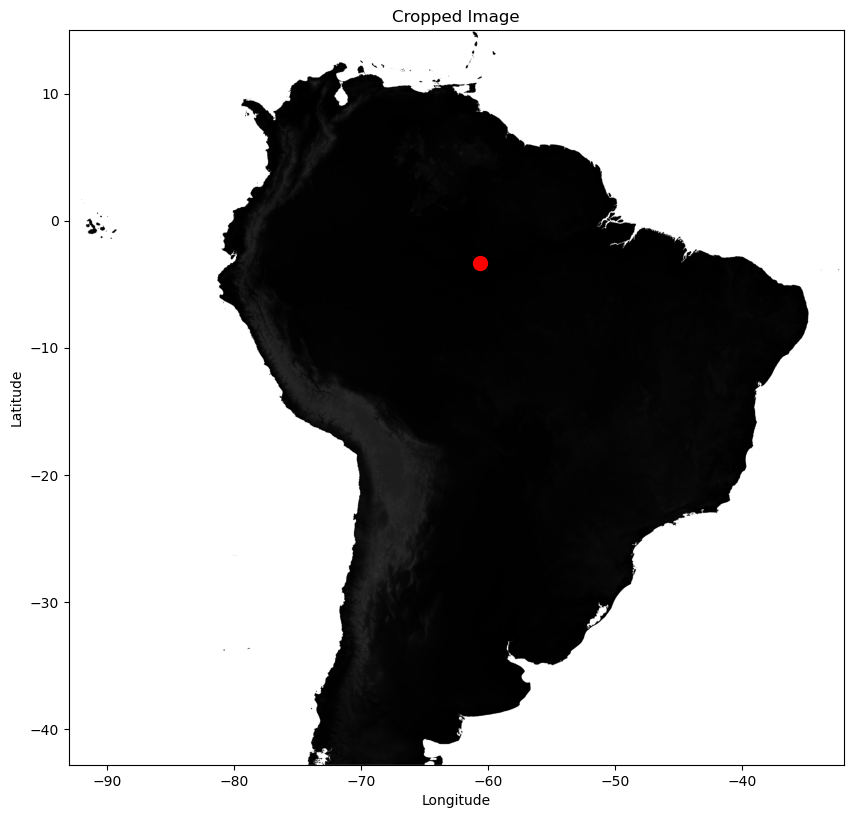


2a: Running delineation part 1...
   Target lon/lat:[-60.6094, -3.3106]
-2

2b: Running delineation part 2...

  STATS-----
   Flow accumulation at point:  2.0
   Max accumulation:  4474073
   Average of full area:  2237037.5
   Window shape: (9, 9)
   Max accumulation in 9x9:  943.0
   Avg accumulation in 9x9:  51.72839506172839
50778840
-60.6094 -3.3106
-60.60833333333335 -3.3249999999995943
   Accumulation at snapped point:  3.0


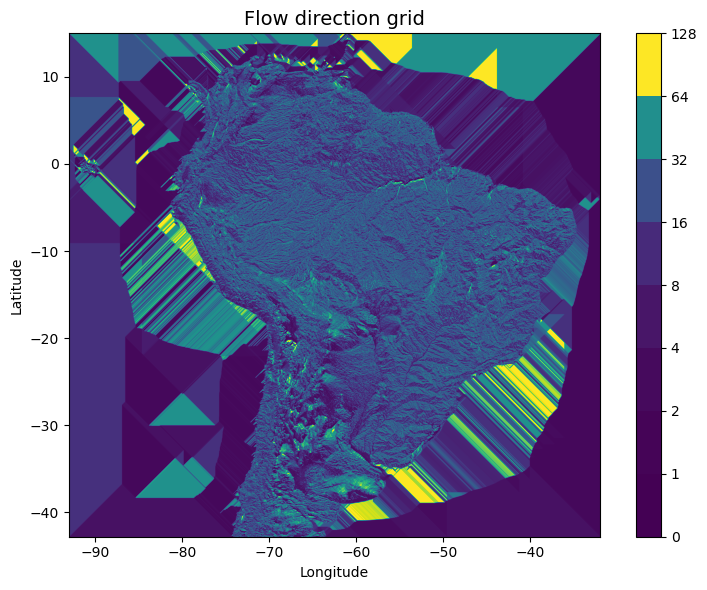

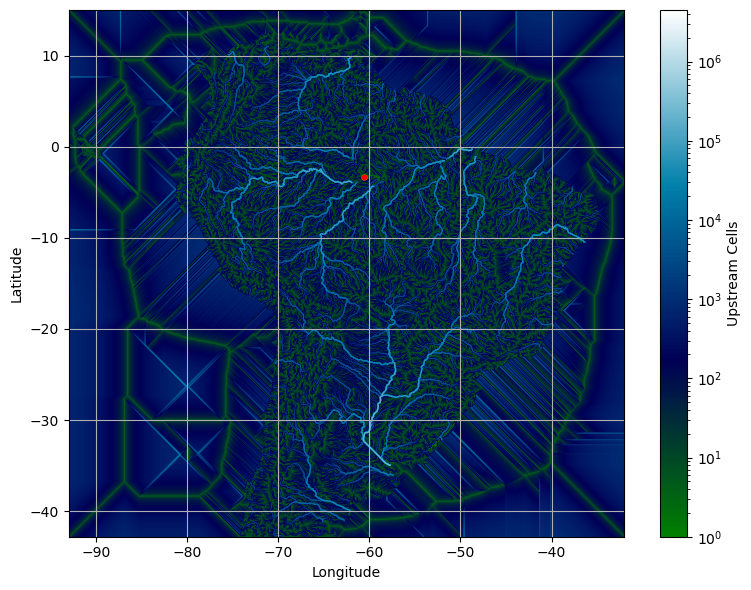


3: Running comparison...


/tmp/ipykernel_740121/2897928620.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_latlon.geometry.centroid


calculated lat/lon, get_utm_espg fxn: -71.6661430136169, -5.629626157434075
 CALCED ESPG: 32719
established area
intersection area: [456374.99362231337]
delin area: [821819115.3484172]
calculated grdc area: [2204770227145.7104]
csv reported grdc area: 2147736.0
2.069943561480033e-05
EPSG:32719
EPSG:32719
-79.6125 -60.36666666666668 -15.5208 2.9375


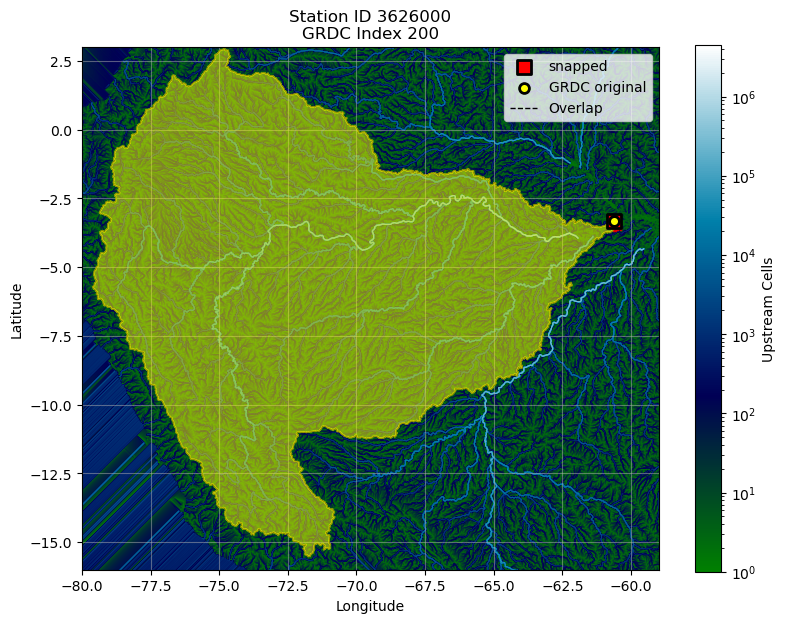

False


In [11]:
# Run the Loop!
bool_plot = True
failed_df = []
random_subset = stations_df[stations_df.index == 200] #if want to do just one...
my_idx = 1 # Counter for loop
for n in random_subset.index:
    try:
        print(f'[{my_idx}]/[{len(random_subset)}]~~ RUNNING RANDOM SUBSET, NUMBER {n} ~~')
        
        '''~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Loop~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'''
        # 1) Crop
        bbox, lat_GRDC, lon_GRDC, area_GRDC_reported, number_GRDC, output_tif_temp, dem_temp = open_and_crop_basin(n, plot_scene = bool_plot)
        
        # 2a) Delineate pt 1 (flow dir grid)
        grid_temp, dem_temp, f_dir_temp, dir_map_temp, shp_name_temp = delineate_basin_1(output_tif_temp, lon_GRDC, lat_GRDC, dem_temp, number_GRDC, plot_scene = bool_plot)
        
        # 2b) Delin pt 2
        catch_view_temp, catch_temp, acc_temp, x_snap_temp, y_snap_temp, acc_atpt, acc_max, avg_full_area_temp, window_shape, max_acc_window, mean_acc_window, acc_area_temp, acc_snapped_temp = delineate_basin_2(grid_temp, dem_temp, f_dir_temp, dir_map_temp, lon_GRDC, lat_GRDC, plot_scene = bool_plot)
        
        # 3) Compare the two shapefiles
        gdf_grdc,grdc_area_temp, intersection_area_temp, inter_pcnt_temp, output_fn, delin_area_temp,del_shp, grdc_shp = compare_catchments(grid_temp, catch_view_temp, acc_temp, catch_temp, x_snap_temp, y_snap_temp, lon_GRDC, lat_GRDC, number_GRDC,shp_name_temp, area_GRDC_reported)

        # 3a) NEW: Check if the grdc is outside dem
        bbox_geom = box(*bbox)
        geom = gdf_grdc.dissolve().geometry.iloc[0]
        is_outside = not geom.within(bbox_geom)
        print(is_outside)
                
        # 4) Append to the df
        new_row = { 
            "Country": random_subset.loc[n].country,
            "Station": number_GRDC, #
            "Index" : n, #
            "lat": lat_GRDC, #
            "lon": lon_GRDC, #
            "lat_snap_y": y_snap_temp, #
            "lon_snap_x": x_snap_temp, #
            "area_grdc_km2": grdc_area_temp[0]/1e6, #
            "area_delineated_km2": delin_area_temp[0]/10**6, #
            "area_intersect_km2": intersection_area_temp[0]/10**6, #
            "pct_intersect": inter_pcnt_temp,# else None, #
            "avg_acc_of_full_area": avg_full_area_temp,
            "img_path": output_fn, #
            "flow_accum_at_pour_pt": acc_atpt, #
            "snapped_accum": acc_snapped_temp, #
            "max_accum": acc_max, #
            "avg_accum": float(acc_temp.mean()), #
            "win_shape": (9, 9), #
            "max_accum_9x9": max_acc_window, #
            "avg_accum_9x9": mean_acc_window, #
            "estimated_distance_km": math.sqrt((lat_GRDC-y_snap_temp)**2 + (lon_GRDC-x_snap_temp)**2)*111,
            "FLAG_small_areaDelin<1000":str(delin_area_temp[0]/10**6<1000), 
            "FLAG_small_snapAcc<100":str(acc_snapped_temp<100), 
            "FLAG_small_Intersec<90":str(inter_pcnt_temp<90), 
            "FLAG_cropping_GRDC>cropDEM":str(is_outside)
        }
        df.loc[len(df)] = new_row
    
        # Save to dir...
        #df_output_dir = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/delineation_stats_UPDATEDDEM_2.csv'
        #df.to_csv(df_output_dir)
    except: 
        failed_df.append(n)
        print(f'Failed {n}... continuing to next')
    my_idx=my_idx+1 # increasing the ctr
    ''' ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ End~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'''

In [ ]:
#-60.95833333333335 -3.333333333332927
#244521607.6716453]
#[2040771078.7995057]

In [98]:
# lat	lon	lat_snap_y	lon_snap_x	area_grdc_km2	area_delineated_km2	area_intersect_km2	pct_intersect
df = pd.read_csv('/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/delineation_stats.csv')
i = 549
df_temp_raw =df[df['Index']==i]
df_temp = df_temp_raw.iloc[0]
print(str(df_temp['lat']) + ', ' + str(df_temp['lon']))
print(str(df_temp['lat_snap_y'])[0:8] + ', ' + str(df_temp['lon_snap_x'])[0:8])
print(str(df_temp_raw['Country']))
print(int(df_temp_raw['Station']))
print(df_temp_raw.iloc[0][['FLAG_small_areaDelin<1000',
       'FLAG_small_snapAcc<100', 'FLAG_small_Intersec<90',
       'FLAG_cropping_GRDC>cropDEM']])

-34.0715, 115.619
-34.0749, 115.575
546    AU
Name: Country, dtype: object
5606100
FLAG_small_areaDelin<1000     False
FLAG_small_snapAcc<100         True
FLAG_small_Intersec<90         True
FLAG_cropping_GRDC>cropDEM     True
Name: 546, dtype: object


/tmp/ipykernel_1894616/3536963604.py:9: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(int(df_temp_raw['Station']))


In [100]:
df_temp_raw[['estimated_distance_km','area_grdc_km2',	
         'area_delineated_km2',	'area_intersect_km2',	'pct_intersect',
         'flow_accum_at_pour_pt',	'snapped_accum', 'max_accum_9x9',
         'avg_accum_9x9']]


,estimated_distance_km,area_grdc_km2,area_delineated_km2,area_intersect_km2,pct_intersect,flow_accum_at_pour_pt,snapped_accum,max_accum_9x9,avg_accum_9x9
546,4.899427,20387.193544,12957.889617,12818.232655,62.873944,197.0,2.0,17944.0,1792.962963


In [48]:
df_temp_raw[['FLAG_small_areaDelin<1000',
       'FLAG_small_snapAcc<100', 'FLAG_small_Intersec<90',
       'FLAG_cropping_GRDC>cropDEM']]

,FLAG_small_areaDelin<1000,FLAG_small_snapAcc<100,FLAG_small_Intersec<90,FLAG_cropping_GRDC>cropDEM
427,True,False,True,True


In [75]:
df[["Index", "Country", "snapped_accum", "area_delineated_km2", "pct_intersect","FLAG_small_areaDelin<1000", "FLAG_small_snapAcc<100", "FLAG_small_Intersec<90", "FLAG_cropping_GRDC>cropDEM"]]

,Index,Country,snapped_accum,area_delineated_km2,pct_intersect,FLAG_small_areaDelin<1000,FLAG_small_snapAcc<100,FLAG_small_Intersec<90,FLAG_cropping_GRDC>cropDEM
0,454,US,43632.0,31213.346719,89.575226,False,False,True,True


### Inspect the saved files

In [11]:
fn_csv = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/delineation_stats.csv'
df_results = pd.read_csv(fn_csv)
df_results

,Unnamed: 0,Station,Index,lat,lon,lat_snap_y,lon_snap_x,area_grdc,area_delineated,area_intersect,...,avg_full_area,img_path,flow_accum_pt,snapped_accum,max_accum,avg_accum,win_shape,max_accum_9x9,avg_accum_9x9,estimated_distance_km
0,0,4149413,422,31.758500,-88.129200,31.725000,-88.100000,47700.0,142053.096183,140362.999681,...,78705.0,/global/scratch/users/cgerlein/fc_ecohydrology...,2.0,67494.0,157408,244.027578,"(9, 9)",67494.0,9162.518519,4.932811
1,1,3650415,307,-7.534400,-46.035800,-7.508333,-46.000000,8800.0,36526.303751,36089.012770,...,112740.0,/global/scratch/users/cgerlein/fc_ecohydrology...,10360.0,10404.0,215120,445.668912,"(9, 9)",10401.0,1281.901235,4.915572
2,2,4118320,352,35.848600,-116.230000,35.808333,-116.208333,8003.1,53226.653772,11603.135752,...,200824.5,/global/scratch/users/cgerlein/fc_ecohydrology...,50074.0,50201.0,351575,365.904953,"(9, 9)",50200.0,5620.111111,5.075564
3,3,2856500,133,18.830000,79.450000,18.808333,79.491667,102900.0,326572.676793,325327.330603,...,189493.5,/global/scratch/users/cgerlein/fc_ecohydrology...,5.0,123760.0,378982,383.548402,"(9, 9)",123751.0,13739.271605,5.212931
4,4,4150500,451,29.582500,-95.757700,29.583333,-95.716667,116827.1,245458.085364,241744.807677,...,145425.0,/global/scratch/users/cgerlein/fc_ecohydrology...,3.0,134031.0,290847,444.804555,"(9, 9)",134027.0,16541.308642,4.555639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,5204107,525,-35.539928,149.101250,-35.491667,149.066667,5158.0,8867.676982,7685.169682,...,30195.5,/global/scratch/users/cgerlein/fc_ecohydrology...,6.0,8449.0,60385,139.769024,"(9, 9)",8428.0,1027.814815,6.590412
86,86,3638150,262,-5.696700,-54.245600,-5.650000,-54.283333,60058.0,438899.750958,396051.825546,...,267771.0,/global/scratch/users/cgerlein/fc_ecohydrology...,68135.0,74781.0,467407,565.819456,"(9, 9)",74765.0,9065.493827,6.664341
87,87,4151802,472,35.874700,-106.142200,35.833333,-106.166667,37037.0,68003.506209,67342.998516,...,68708.5,/global/scratch/users/cgerlein/fc_ecohydrology...,5.0,52991.0,137412,240.014104,"(9, 9)",52713.0,5207.456790,5.334724
88,88,1234150,83,13.520000,2.090000,13.483333,2.125000,700000.0,2.619927,1.748310,...,1628241.5,/global/scratch/users/cgerlein/fc_ecohydrology...,2.0,1465676.0,3256481,945.068319,"(9, 9)",1465676.0,162851.024691,5.626555


In [17]:
missing_indices = random_subset.index.difference(df_results['Index'])
missing_indices

Index([137, 139, 140, 177, 192, 194, 195, 199, 210, 212], dtype='int64')

In [40]:
# Look at columns with low percentage
df_results_min = df_results[df_results['pct_intersect']<30]
df_results_min.head()

,Unnamed: 0,Station,Index,lat,lon,lat_snap_y,lon_snap_x,area_grdc,area_delineated,area_intersect,...,avg_full_area,img_path,flow_accum_pt,snapped_accum,max_accum,avg_accum,win_shape,max_accum_9x9,avg_accum_9x9,estimated_distance_km
14,14,3649902,296,-5.789400,-47.468900,-5.741667,-47.491667,298559.0,4.061954,4.037720,...,615130.5,/global/scratch/users/cgerlein/fc_ecohydrology...,6.0,344253.0,1230255,670.198380,"(9, 9)",344197.0,38240.098765,5.870202
21,21,5404270,542,-34.178700,140.275000,-34.166667,140.233333,1000001.0,2.588955,0.968228,...,1615016.5,/global/scratch/users/cgerlein/fc_ecohydrology...,1393832.0,1393868.0,1836201,529.488568,"(9, 9)",1393856.0,154872.641975,4.814013
24,24,1992850,115,-16.084722,35.668056,-16.108333,35.625000,19300.0,641.805946,212.143267,...,58495.0,/global/scratch/users/cgerlein/fc_ecohydrology...,228.0,1.0,116762,203.824418,"(9, 9)",663.0,76.543210,5.450670
28,28,3652890,333,-21.753300,-41.300300,-21.758333,-41.266667,55500.0,85.200429,38.177932,...,51641.5,/global/scratch/users/cgerlein/fc_ecohydrology...,12.0,1.0,103271,142.087287,"(9, 9)",41.0,3.753086,3.774874
30,30,5109201,506,-15.942400,142.374000,-15.983333,142.375000,45000.0,1.986871,1.986871,...,37412.5,/global/scratch/users/cgerlein/fc_ecohydrology...,1.0,1.0,74824,136.297168,"(9, 9)",55381.0,2055.160494,4.544956


PCT Intersection: 0.0044152695198431
INDEX: 506


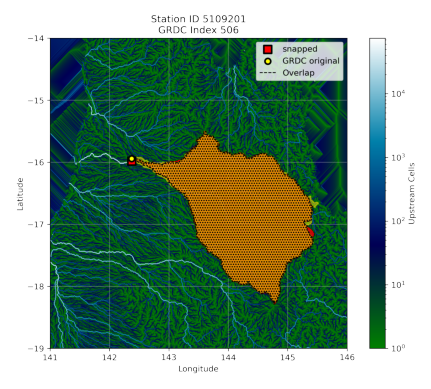

In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img_n = 4
# Read and show image
img = mpimg.imread(df_results_min['img_path'].iloc[img_n])
print(f"PCT Intersection: {df_results_min['pct_intersect'].iloc[img_n]}")
print(f"INDEX: {df_results_min['Index'].iloc[img_n]}")
plt.imshow(img)
plt.axis('off')  # optional: hide axes
plt.show()


#### Check failed runs

In [27]:
random_subset

,grdc_no,wmo_reg,sub_reg,river,station,country,lat,long,area,altitude,...,m_start,m_end,m_yrs,m_miss,t_start,t_end,t_yrs,lta_discharge,r_volume_yr,r_height_yr
422,4149413,4,4491,TOMBIGBEE RIVER,"COFFEEVILLE L+D NEAR COFFEEVILLE, AL",US,31.758500,-88.129200,47700.0,-999.00,...,NaN,NaN,NaN,NaN,1960,2021,62,841.031,26.522753616,556.0325705660376
307,3650415,3,3508,RIO DAS BALSAS,BALSAS,BR,-7.534400,-46.035800,8800.0,235.00,...,1965.0,1993.0,29.0,0.593472,1965,2020,56,100.853,3.180500208,361.4204781818182
352,4118320,4,4180,AMARGOSA RIVER,"TECOPA, CA",US,35.848600,-116.230000,8003.1,399.29,...,1961.0,2000.0,40.0,39.743590,1961,2023,63,0.077,0.002428272,0.3034164261348727
194,3621400,3,3211,RIO CAQUETA,VILA BITTENCOURT,BR,-1.394700,-69.428300,197136.0,-999.00,...,1980.0,1993.0,14.0,1.273885,1980,2020,41,13931.837,439.354411632,2228.686853907962
133,2856500,2,2561,GODAVARI RIVER,MANCHERIAL,IN,18.830000,79.450000,102900.0,124.00,...,1968.0,2024.0,57.0,9.037037,1968,2024,57,299.712,9.451717632,91.8534269387755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,3142500,3,3421,RIO PATIA,PTE PUSMEO,CO,1.706250,-77.510410,13147.0,1975.00,...,1965.0,2021.0,57.0,20.000000,1965,2021,57,316.85,9.9921816,760.0351106716362
83,1234150,1,1341,RIVER NIGER,NIAMEY,NE,13.520000,2.090000,700000.0,174.85,...,1929.0,2012.0,84.0,34.830339,1929,2024,96,896.579,28.274515344,40.39216477714285
137,3103100,3,3031,RIO CAUCA,LA VIRGINIA,CO,4.880000,-75.880000,22814.0,-999.00,...,1946.0,2024.0,79.0,0.105820,1946,2024,79,550.182,17.350539552,760.521589900938
212,3633123,3,3331,RIO YURUA,IPIXUNA,BR,-7.055600,-71.689200,55806.0,-999.00,...,NaN,NaN,NaN,NaN,1981,2019,39,1377.233,43.432419888,778.2750938608751



1: Running crop method...
  Station 5204101
   name: D/S MAUDE WEIR
   region: 5
   lon,lat: 144.301,-34.4776
   DEM: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_au_dem_30s.tif


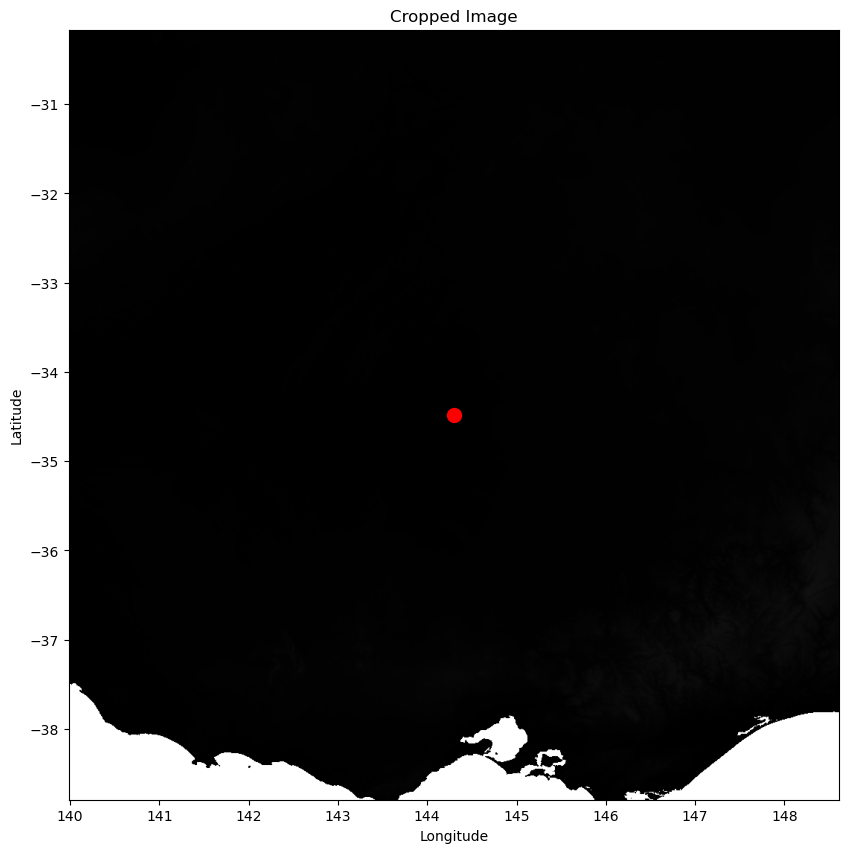


2a: Running delineation part 1...
   Target lon/lat:[144.301, -34.4776]
-2

2b: Running delineation part 2...

  STATS-----
   Flow accumulation at point:  1.0
   Max accumulation:  669277
   Average of full area:  334639.0
   Window shape: (9, 9)
   Max accumulation in 9x9:  57.0
   Avg accumulation in 9x9:  5.802469135802469
1072260
144.301 -34.4776
144.29166666666663 -34.51666666666621
   Accumulation at snapped point:  1.0


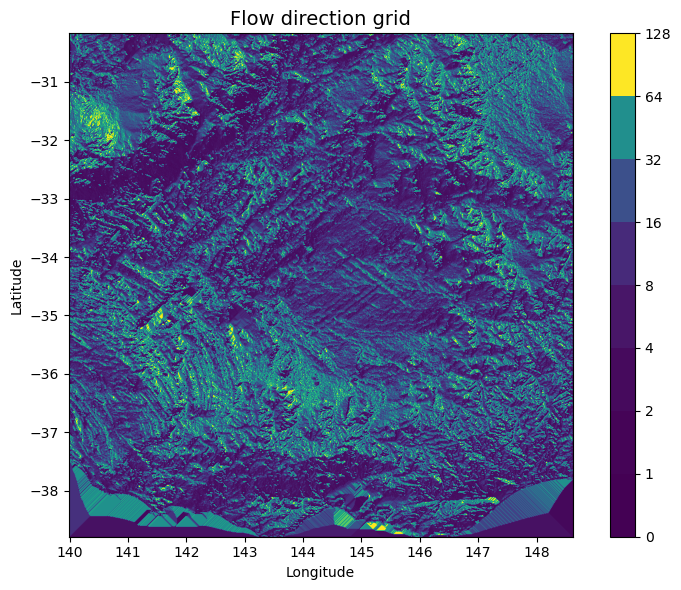

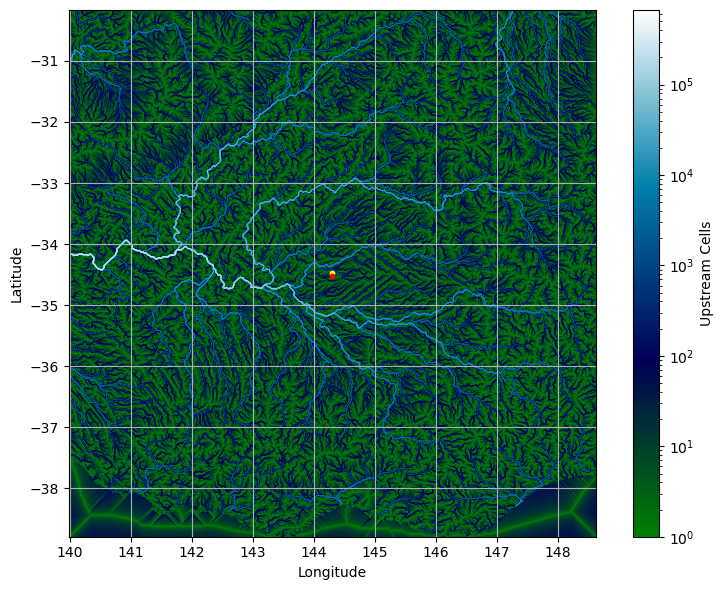


3: Running comparison...
intersection area: 0    7.026232e+07
1    7.026232e+07
dtype: float64
delin area: 0    7.026232e+07
1    7.026232e+07
dtype: float64
EPSG:32633
EPSG:32633
144.2667 149.5792 -36.55 -34.3542


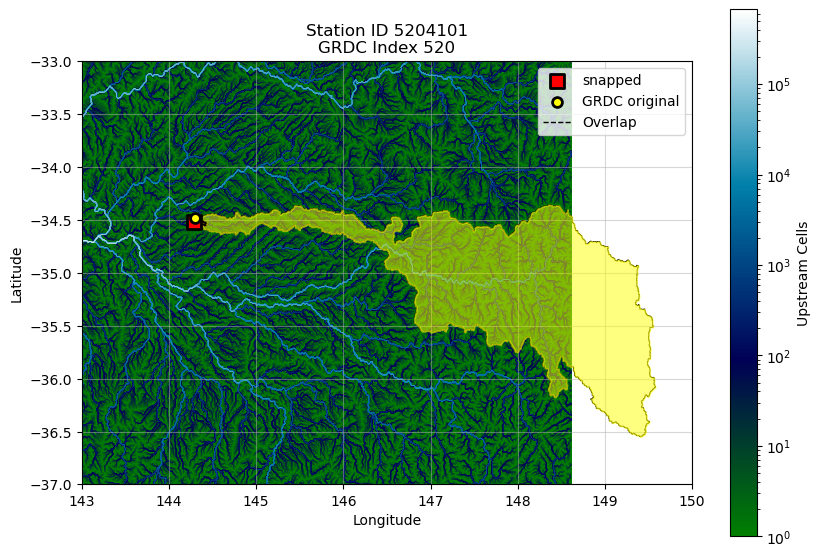

ValueError: too many values to unpack (expected 3)

In [43]:
n = 520
'''~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Loop~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'''
# 1) Crop
lat_GRDC, lon_GRDC, area_GRDC, number_GRDC, output_tif_temp, dem_temp = open_and_crop_basin(n, plot_scene = True)

# 2a) Delineate pt 1 (flow dir grid)
grid_temp, dem_temp, f_dir_temp, dir_map_temp, shp_name_temp = delineate_basin_1(output_tif_temp, lon_GRDC, lat_GRDC, dem_temp, number_GRDC, plot_scene = True)

# 2b) Delin pt 2
catch_view_temp, catch_temp, acc_temp, x_snap_temp, y_snap_temp, acc_atpt, acc_max, avg_full_area_temp, window_shape, max_acc_window, mean_acc_window, acc_area_temp, acc_snapped_temp = delineate_basin_2(grid_temp, dem_temp, f_dir_temp, dir_map_temp, lon_GRDC, lat_GRDC, plot_scene = True)

# 3) Compare the two shapefiles
intersection_area_temp, inter_pcnt_temp, output_fn = compare_catchments(grid_temp, catch_view_temp, acc_temp, catch_temp, x_snap_temp, y_snap_temp, lon_GRDC, lat_GRDC, number_GRDC,shp_name_temp, acc_area_temp)


#### ------- End sls loop ---------------

In [28]:
# Pull station
i = 26
data = stations_df.iloc[i]

# Assign vars
number = data['grdc_no']
region = data['wmo_reg']
river = data['river']
name = data['station']
lat = data['lat']
lon = data['long']
lat_grdc = lat #store var
lon_grdc = lon # '''
area = data['area']
area_grdc = area # '''
altitude = data['altitude']
print(f'Station {number}\n   name: {name}\n   region: {region}\n   lon,lat: {lon},{lat}')

Station 1159555
   name: WOODLANDS
   region: 1
   lon,lat: 27.59197,-26.73828


In [29]:
# Assign loc
SCRATCH_DIR = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM'
if region == 1:
  dem = f'{SCRATCH_DIR}/hyd_af_dem_30s.tif'
elif region == 2:
  dem = f'{SCRATCH_DIR}/hyd_as_dem_30s.tif'
elif region == 3:
  dem = f'{SCRATCH_DIR}/hyd_sa_dem_30s.tif'
elif region == 4:
  dem = f'{SCRATCH_DIR}/hyd_na_dem_30s.tif'
elif region == 5:
  dem = f'{SCRATCH_DIR}/hyd_au_dem_30s.tif'
elif region == 6:
  dem = f'{SCRATCH_DIR}/hyd_eu_dem_30s.tif'
print(f'DEM: {dem}')
output_tif = f'/global/scratch/users/slsmit34/299/STATIONS/{number}_dem.tif'

DEM: /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/hyd_af_dem_30s.tif


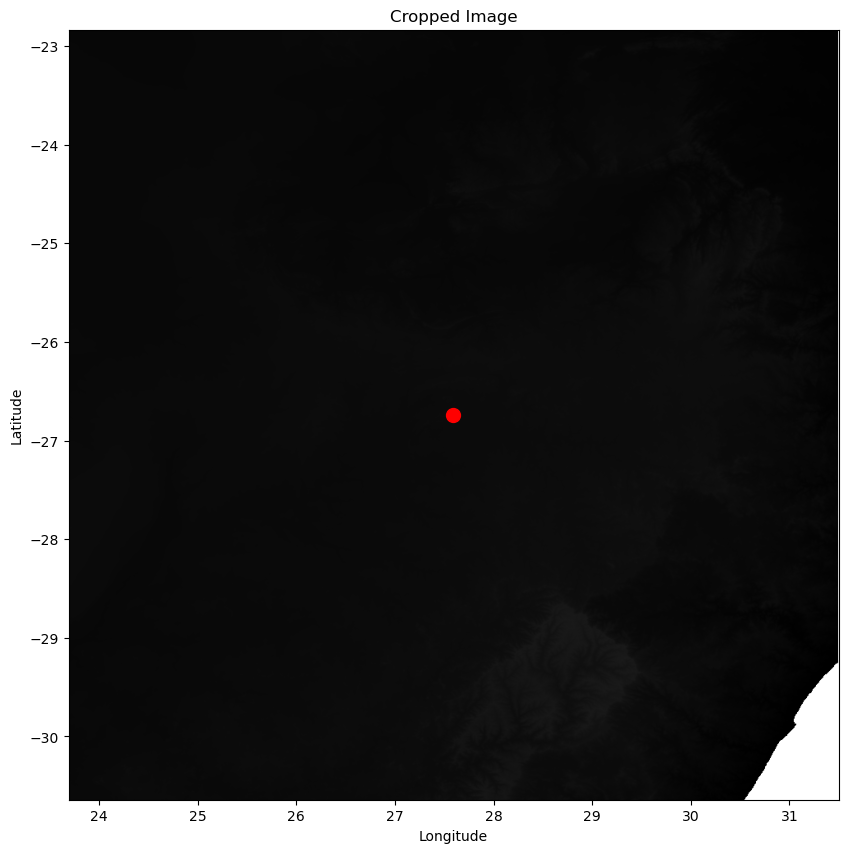

In [30]:
# Crop continent, save to dir
crop_dem(dem, output_tif, lon, lat,area)

In [31]:
# Delineate Basin

# Load the .tif file for the DEM
tif_input = output_tif
pour_point = [lon,lat]
print(pour_point)

# Define the path for the new shapefile
new_folder_path = f'/global/scratch/users/slsmit34/299/STATIONS/{number}/'

# Create the folder and filepath
os.makedirs(new_folder_path, exist_ok=True)
shp_name = new_folder_path + f'{number}.shp'

[27.59197, -26.73828]


In [32]:
# Initialize a grid from the raster
grid = Grid.from_raster(tif_input, data_name='dem')
dem = grid.read_raster(tif_input)

In [33]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)

In [34]:
# Define the flow direction map (Dirmap)
dir_map = (64, 128, 1, 2, 4, 8, 16, 32)

# Compute flow directions from DEM
f_dir = grid.flowdir(inflated_dem, dirmap=dir_map)  # returns a Raster object
print(np.nanmin(f_dir))

-2


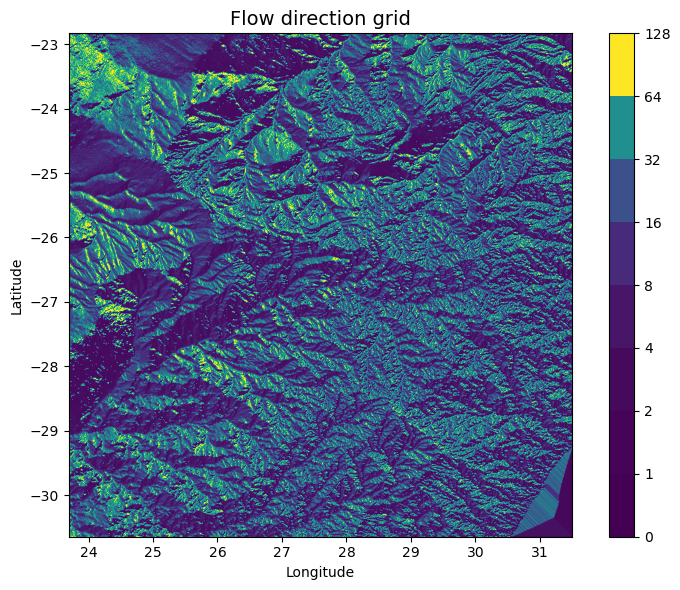

In [35]:
# Plot the flow direction map
fig = plt.figure(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(f_dir, extent=grid.extent, cmap='viridis', zorder=2)
plt.scatter(lon, lat, color='red', marker='o', s=100, label="Center Point")
boundaries = ([0] + sorted(list(dir_map)))
plt.colorbar(boundaries= boundaries,
             values=sorted(dir_map))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow direction grid', size=14)
plt.grid(zorder=-1)
plt.tight_layout()

In [36]:
# Get Accumulation
acc = grid.accumulation(f_dir, dirmap=dir_map)
acc[dem==0] = 0

In [43]:
# Delineate the basin.... (again?)-----
row, col = rowcol(acc.affine, lon, lat)
# Access the accumulation value
acc_atpt = acc.view()[row, col]
acc_max = int(acc.max())
arr = acc.view()

# Define half-window size (9x9 = 4 px in each direction)
half_size = 4

# Create a window around the pour-point to snap to
row_start = max(0, row - half_size)
row_end   = min(arr.shape[0], row + half_size + 1)
col_start = max(0, col - half_size)
col_end   = min(arr.shape[1], col + half_size + 1)

# Extract the window
window = arr[row_start:row_end, col_start:col_end]

In [44]:
# Exported metrics
print("Flow accumulation at point: ", acc_atpt)
print("Max accumulation: ", acc_max)
print("Average of full area: ", ((acc_max+acc_atpt)/2))
print("Window shape:", window.shape)
print("Max accumulation in 9x9: ", np.max(window)) 
print("Avg accumulation in 9x9: ", np.mean(window)) 

Flow accumulation at point:  60744.0
Max accumulation:  254860
Average of full area:  157802.0
Window shape: (9, 9)
Max accumulation in 9x9:  60910.0
Avg accumulation in 9x9:  11258.444444444445


In [45]:
# Define the accumulation of the snapped point
snap_pt = np.max(window)
x_snap, y_snap = grid.snap_to_mask(acc > snap_pt, (lon, lat))
catch = grid.catchment(x=x_snap, y=y_snap, fdir=f_dir, dirmap=dir_map,
                          xytype='coordinate')

# Convert lon/lat to raster indices
row_snap, col_snap = rowcol(acc.affine, x_snap, y_snap)
# Access the accumulation value
acc_snapped = acc.view()[row_snap, col_snap]
print(np.size(acc))
print(lon,lat)
print(x_snap, y_snap)
print("Accumulation at snapped point: ", acc_snapped)

877969
27.59197 -26.73828
27.54999999999998 -26.766666666666666
Accumulation at snapped point:  5.0


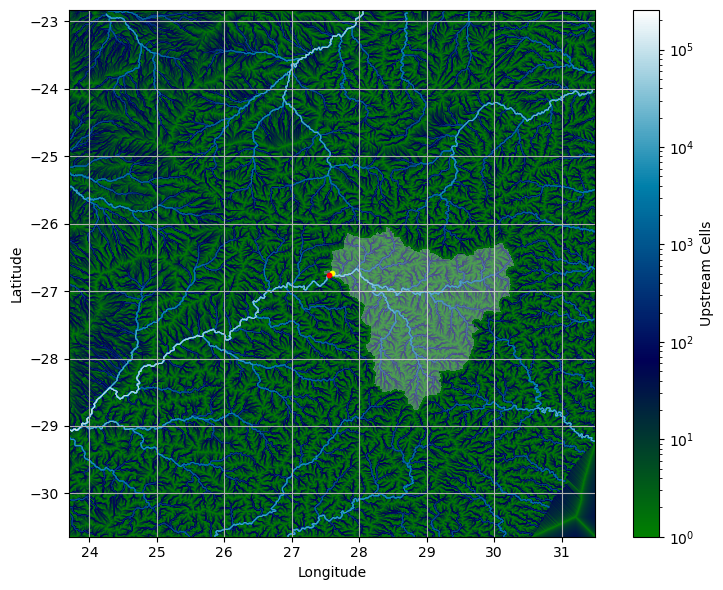

In [46]:
# # Clip the bounding box to the catchment
# grid.clip_to(catch)
catch_view = grid.view(catch, dtype=np.uint8)

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=catch.extent, zorder=1,
                cmap='ocean',
                norm=colors.LogNorm(1, acc.max()),
                interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.imshow(np.where(catch_view,catch_view, np.nan), extent=grid.extent,zorder=2, cmap='Greys',alpha=0.3)
plt.scatter(lon,lat, color='yellow', s=10, marker='o', zorder=3)
plt.scatter(x_snap,y_snap, color='red', s=10, marker='o', zorder=3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## Compare delineated and GRDC shapefiles

In [ ]:
def extract_holes(geom):
    """Return holes (interior rings) as polygons."""
    holes = []
    if geom.geom_type == "Polygon":
        for interior in geom.interiors:
            holes.append(Polygon(interior))
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            for interior in poly.interiors:
                holes.append(Polygon(interior))
    return holes

def compare_catchments(grid, catch_view, acc, catch, x_snap, y_snap, lon, lat):
    shapes = grid.polygonize(catch_view)

    # Specify schema
    schema = {
            'geometry': 'Polygon',
            'properties': {'LABEL': 'float:16'}
    }

    # Write shapefile of the delineated catchment
    shp_output = shp_name
    with fiona.open(
        shp_output,
        'w',
        driver='ESRI Shapefile',
        crs=grid.crs.srs,
        schema=schema
    ) as c:
        i = 0
        for geom, value in shapes:
            g = shape(geom)
    
            # Extract interior rings (the regions you actually want)
            holes = extract_holes(g)
    
            # If no holes, just write the geometry itself
            if not holes:
                rec = {
                    "geometry": g.__geo_interface__,
                    "properties": {"LABEL": str(value)},
                    "id": str(i),
                }
                c.write(rec)
                i += 1
            else:
                # Write each hole as its own polygon feature
                for h in holes:
                    rec = {
                        "geometry": h.__geo_interface__,
                        "properties": {"LABEL": str(value)},
                        "id": str(i),
                    }
                    c.write(rec)
                    i += 1
                    
    # Read the shapefiles
    delin_shp = gpd.read_file(shp_output) # delineated shapefile
    # shapefile1 = catch_view
    grdc_shp = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp') # GRDC shapefile
    
    # Step 3: Reproject to a projected CRS (e.g., UTM Zone 33N, replace EPSG:32633 as appropriate)
    projected_crs = grdc_shp.to_crs(epsg=32633)  # Use an appropriate EPSG for your region
    delin_shp = delin_shp.to_crs(projected_crs.crs)
    grdc_shp = grdc_shp.to_crs(projected_crs.crs)
    
    # Calculate the intersection
    intersection = gpd.overlay(delin_shp, grdc_shp, how='intersection')
    print(intersection)
    
    # Calculate the area of the intersection
    intersection_area = intersection.geometry.area
    
    print(intersection_area[0]/10**6) # 10^6 conversion for m2 to km2
    print(area)

    inter_pcnt = ((intersection_area[0]/10**6)/area)*100 # NEED TO FIX
    print("Intersection percentage:", inter_pcnt)

    # save plot
    gdf_delin = gpd.read_file(shp_output)
    gdf_grdc = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp')
    
    fig, ax = plt.subplots(figsize=(8,6))
    fig.patch.set_alpha(0)
    
    # Flow accumulation background
    im = ax.imshow(
        acc,
        extent=catch.extent,
        zorder=1,
        cmap="ocean",
        norm=colors.LogNorm(1, acc.max()),
        interpolation="bilinear"
    )
    
    # Colorbar
    plt.colorbar(im, ax=ax, label="Upstream Cells")
    
    # Overlay shapefiles instead of NaN mask
    gdf_delin.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=2)
    gdf_delin.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.7, zorder=2)
    
    gdf_grdc.boundary.plot(ax=ax, edgecolor="orange", linewidth=1.5, zorder=2)
    gdf_grdc.plot(ax=ax, facecolor="yellow", edgecolor="orange", alpha=0.3, zorder=2)
    
    # Snap point
    ax.scatter(x_snap, y_snap, color="red", s=50, marker="o", zorder=3)
    ax.scatter(lon, lat, color="yellow", s=50, marker="o", zorder=3)
    
    # Labels, formatting
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, zorder=0)
    # ADD A LEGEND
    
    
    plt.tight_layout()
    plt.savefig(f'/global/scratch/users/slsmit34/299/intersection_delin_plots/{number}_{n}.png',dpi=300, bbox_inches='tight')
    plt.show()
    return(intersection_area, inter_pcnt)

In [100]:
# Create a vector representation of the catchment mask
shapes = grid.polygonize(catch_view)

# Specify schema
schema = {
        'geometry': 'Polygon',
        'properties': {'LABEL': 'float:16'}
}

def extract_holes(geom):
    """Return holes (interior rings) as polygons."""
    holes = []
    if geom.geom_type == "Polygon":
        for interior in geom.interiors:
            holes.append(Polygon(interior))
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            for interior in poly.interiors:
                holes.append(Polygon(interior))
    return holes

# Write shapefile of the delineated catchment
shp_output = shp_name
with fiona.open(
    shp_output,
    'w',
    driver='ESRI Shapefile',
    crs=grid.crs.srs,
    schema=schema
) as c:
    i = 0
    for geom, value in shapes:
        g = shape(geom)

        # Extract interior rings (the regions you actually want)
        holes = extract_holes(g)

        # If no holes, just write the geometry itself
        if not holes:
            rec = {
                "geometry": g.__geo_interface__,
                "properties": {"LABEL": str(value)},
                "id": str(i),
            }
            c.write(rec)
            i += 1
        else:
            # Write each hole as its own polygon feature
            for h in holes:
                rec = {
                    "geometry": h.__geo_interface__,
                    "properties": {"LABEL": str(value)},
                    "id": str(i),
                }
                c.write(rec)
                i += 1


In [101]:
# Read the shapefiles
delin_shp = gpd.read_file(shp_output) # delineated shapefile
# shapefile1 = catch_view
grdc_shp = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp') # GRDC shapefile

# Step 3: Reproject to a projected CRS (e.g., UTM Zone 33N, replace EPSG:32633 as appropriate)
projected_crs = grdc_shp.to_crs(epsg=32633)  # Use an appropriate EPSG for your region
delin_shp = delin_shp.to_crs(projected_crs.crs)
grdc_shp = grdc_shp.to_crs(projected_crs.crs)

# Calculate the intersection
intersection = gpd.overlay(delin_shp, grdc_shp, how='intersection')
print(intersection)

# Calculate the area of the intersection
intersection_area = intersection.geometry.area

print(intersection_area[0]/10**6) # 10^6 conversion for m2 to km2
print(area)

   LABEL    grdc_no       river    station     area  altitude  lat_org  \
0      1  1159555.0  VAAL RIVER  WOODLANDS  47222.0    -999.0 -26.7383   
1      0  1159555.0  VAAL RIVER  WOODLANDS  47222.0    -999.0 -26.7383   

   long_org   lat_pp  long_pp  dist_km  area_calc quality       type  \
0    27.592 -26.7396  27.5896      0.3    47207.7    High  Automatic   
1    27.592 -26.7396  27.5896      0.3    47207.7    High  Automatic   

                                      comment      source  \
0  Area difference <= 5% and distance <= 5 km  hydrosheds   
1  Area difference <= 5% and distance <= 5 km  hydrosheds   

                                            geometry  
0  POLYGON ((1848671.875 -2949463.224, 1848622.79...  
1  POLYGON ((1848671.875 -2949463.224, 1848622.79...  
48356.12307138991
47222.0


In [102]:
# Calculate the percent of area intersected between the two shapefiles
inter_pcnt = ((intersection_area[0]/10**6)/area)*100 # NEED TO FIX
print("Intersection percentage:", inter_pcnt)

# if inter_pcnt >= 50:
#   shapefile = shp_output
#   shp_log[i] = 1

# else:
#     shapefile = f'/global/scratch/users/arvalcarcel/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp'
#     shp_log[i] = 2

# grdc_shp = shp_log[shp_log == 2]
# print("Number of GRDC Shapefiles used: ", len(grdc_shp))

Intersection percentage: 102.40168368851363


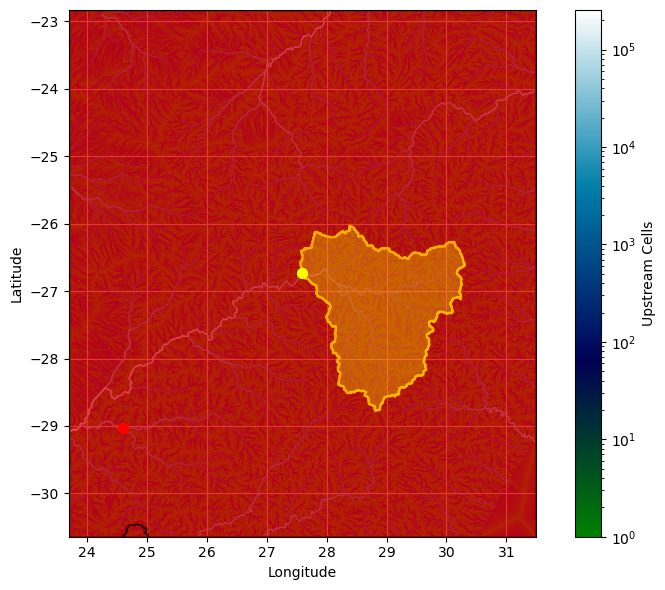

In [128]:
# Load shapefiles as gdfs
gdf_delin = gpd.read_file(shp_output)
gdf_grdc = gpd.read_file(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/SHAPEFILES/{number}/{number}.shp')

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

# Flow accumulation background
im = ax.imshow(
    acc,
    extent=catch.extent,
    zorder=1,
    cmap="ocean",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear"
)

# Colorbar
plt.colorbar(im, ax=ax, label="Upstream Cells")

# Overlay shapefiles instead of NaN mask
gdf_delin.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=2)
gdf_delin.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.7, zorder=2)

gdf_grdc.boundary.plot(ax=ax, edgecolor="orange", linewidth=1.5, zorder=2)
gdf_grdc.plot(ax=ax, facecolor="yellow", edgecolor="orange", alpha=0.3, zorder=2)

# Snap point
ax.scatter(x_snap, y_snap, color="red", s=50, marker="o", zorder=3)
ax.scatter(lon, lat, color="yellow", s=50, marker="o", zorder=3)

# Labels, formatting
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, zorder=0)
# ADD A LEGEND


plt.tight_layout()
plt.savefig(f'/global/scratch/users/slsmit34/299/intersection_delin_plots/{number}_{n}.png',dpi=300, bbox_inches='tight')
plt.show()


In [108]:
index

NameError: name 'index' is not defined

## OPTIONAL: Visualize delineated basin shapefile

In [26]:
# # Load shapefile
# shp = gpd.read_file(shapefile).to_crs("EPSG:4326")

# def extract_holes(geom):
#     holes = []
#     if geom.geom_type == 'Polygon':
#         for interior in geom.interiors:
#             holes.append(Polygon(interior))
#     elif geom.geom_type == 'MultiPolygon':
#         for poly in geom.geoms:
#             for interior in poly.interiors:
#                 holes.append(Polygon(interior))
#     return holes

# # Collect holes from all geometries
# holes = []
# for g in shp.geometry:
#     holes.extend(extract_holes(g))

# # Decide what to plot
# if holes:  # If we found holes, use them
#     gdf_to_plot = gpd.GeoDataFrame(geometry=holes, crs=shp.crs)
#     title = "Shapefile Visualization (holes)"
# else:      # Otherwise, just use the shapefile as-is
#     gdf_to_plot = shp
#     title = "Shapefile Visualization (No Holes Detected)"

# # Plot
# ax = gdf_to_plot.plot(facecolor="blue", edgecolor="black", figsize=(6,6))
# ax.set_title(title)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

## OPTIONAL: Generate random points and delineate basin

In [27]:
yi_s = np.random.randint(0, grid.shape[0], size=10)
xi_s = np.random.randint(0, grid.shape[1], size=10)
xs, ys = grid.affine * (xi_s, yi_s)

In [28]:
z0 = np.zeros(grid.shape)
i = 0

for x, y in zip(xs, ys):
    i += 1
    c = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, xytype='label', inplace=False)
    z0 += i * (c != 0).astype(int)

NameError: name 'fdir' is not defined

## OPTIONAL: Delineate basin from snapped points

In [ ]:
# x_snap, y_snap = grid.snap_to_mask(acc > snap_pt, xy)
new_xy = grid.snap_to_mask(acc > snap_pt, xy, return_dist=False)
new_xs, new_ys = new_xy[:,0], new_xy[:,1]

In [ ]:
z1 = np.zeros(grid.shape)
i = 0

for x, y in zip(new_xs, new_ys):
    i += 1
    c = grid.catchment(x, y, fdir=fdir, dirmap=dirmap, xytype='label', inplace=False)
    z1 += i * (c != 0).astype(int)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

z0[z0 == 0] = np.nan
z1[z1 == 0] = np.nan

ax[0].imshow(z0, extent=grid.extent, zorder=1, cmap='plasma')
ax[0].scatter(xy[:,0], xy[:,1], marker='x', c='k', zorder=2)
ax[0].set_title('Catchments at original coordinates')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

ax[1].imshow(z1, extent=grid.extent, zorder=1, cmap='plasma')
ax[1].scatter(new_xy[:,0], new_xy[:,1], marker='x', c='k', zorder=2)
ax[1].set_title('Catchments at snapped coordinates')
ax[1].set_xlabel('Longitude')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')

plt.scatter(xs, ys, marker='x', c='b', s=100, label='original')
plt.scatter(new_xs, new_ys, marker='x', c='r', s=100, label='snapped')
plt.legend(frameon=True)
plt.imshow(np.where(acc > 100, 1, np.nan), extent=grid.extent, cmap='bone', zorder=1, alpha=0.8)
plt.title('Original vs. snapped coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')